# 🔥 Machine Vision — Multi-Scale Thermal Animal Detection
## Master Training Notebook — All 4 Models

**Project:** Thermal Animal Detection for Nighttime African Road Safety  
**Authors:** Kupakwashe T. Mapuranga | Shoeb Shakil Sutar  
**Institution:** Symbiosis Institute of Technology (SIT), Dept. of AIML  
**Target:** IEEE Transactions on Intelligent Transportation Systems  

---

### Models Trained (identical hyperparameters for fair comparison)
| # | Model | Type | Novel? |
|---|---|---|---|
| 1 | YOLOv8s | CNN Baseline | No |
| 2 | YOLOv9c | PGI + GELAN | No |
| 3 | RT-DETR-L | Transformer | No |
| 4 | Inception-YOLOv8 | Multi-scale CNN | **Yes — Novel** |

### Instructions
1. Runtime → Change runtime type → **A100 GPU**
2. Run **Section 0** (setup) once
3. Run **Section 1** (dataset) once
4. Run each model section independently — they save to Drive automatically
5. Run **Section 6** (benchmark) after all 4 models complete

---
## Section 0 — Environment Setup


In [1]:
# ── 0.1 Check GPU ──────────────────────────────────────────────────
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Fri Apr 10 14:49:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             49W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [8]:
# ── 0.2 Install dependencies ───────────────────────────────────────
!pip install ultralytics==8.4.14 -q
!pip install torch torchvision -q

# Verify
import ultralytics
print(f'Ultralytics: {ultralytics.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics: 8.4.14


In [3]:
# ── 0.3 Mount Google Drive ─────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os

# Project root on Drive — adjust if your folder name differs
DRIVE_ROOT = '/content/drive/MyDrive/Colab Notebooks/sem II/thermal_animal_detection'
os.makedirs(DRIVE_ROOT, exist_ok=True)

# All results will save here — persists after session ends
RESULTS_DIR = f'{DRIVE_ROOT}/results'
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f'Drive mounted at: {DRIVE_ROOT}')
print(f'Results will save to: {RESULTS_DIR}')

Mounted at /content/drive
Drive mounted at: /content/drive/MyDrive/Colab Notebooks/sem II/thermal_animal_detection
Results will save to: /content/drive/MyDrive/Colab Notebooks/sem II/thermal_animal_detection/results


In [9]:
import torch
import torch.nn as nn
import ultralytics.nn.modules as ult_modules
import ultralytics.nn.tasks as _tasks
import ultralytics.nn.tasks

class InceptionModule(nn.Module):
    def __init__(self, c1, c2=None):
        super().__init__()
        if c2 is None:
            c2 = c1
        b1 = c2 // 4
        b2 = c2 // 4
        b3 = c2 // 8
        b4 = c2 - b1 - b2 - b3
        self.branch1 = nn.Sequential(
            nn.Conv2d(c1, b1, kernel_size=1, bias=False),
            nn.BatchNorm2d(b1), nn.SiLU(inplace=True)
        )
        self.branch2 = nn.Sequential(
            nn.Conv2d(c1, b2 // 2, kernel_size=1, bias=False),
            nn.BatchNorm2d(b2 // 2), nn.SiLU(inplace=True),
            nn.Conv2d(b2 // 2, b2, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(b2), nn.SiLU(inplace=True)
        )
        self.branch3 = nn.Sequential(
            nn.Conv2d(c1, max(b3 // 4, 1), kernel_size=1, bias=False),
            nn.BatchNorm2d(max(b3 // 4, 1)), nn.SiLU(inplace=True),
            nn.Conv2d(max(b3 // 4, 1), b3, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm2d(b3), nn.SiLU(inplace=True)
        )
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(c1, b4, kernel_size=1, bias=False),
            nn.BatchNorm2d(b4), nn.SiLU(inplace=True)
        )
        self.out_channels = b1 + b2 + b3 + b4

    def forward(self, x):
        return torch.cat([
            self.branch1(x),
            self.branch2(x),
            self.branch3(x),
            self.branch4(x)
        ], dim=1)

# Register in all three places Ultralytics checks
_tasks.InceptionModule = InceptionModule
_modules = ult_modules
_modules.InceptionModule = InceptionModule
ultralytics.nn.tasks.__dict__['InceptionModule'] = InceptionModule

print('InceptionModule registered successfully.')
print('Check:', 'InceptionModule' in ultralytics.nn.tasks.__dict__)

InceptionModule registered successfully.
Check: True


---
## Section 1 — Dataset Setup
Run once. Extracts dataset from Drive to fast Colab local storage.

In [14]:
import shutil
shutil.rmtree('/content/dataset')
print('Cleaned.')

Cleaned.


In [13]:
# ── 1.1 Extract dataset to local fast storage ──────────────────────
import os, zipfile, shutil

DATASET_ZIP        = f'{DRIVE_ROOT}/dataset/final_dataset_v3.zip'
FINAL_DATASET_PATH = '/content/dataset/final_dataset_v3'
TEMP_EXTRACT_DIR   = '/content/temp_dataset_extraction'
DATASET_LOCAL      = FINAL_DATASET_PATH

if not os.path.exists(f'{FINAL_DATASET_PATH}/images/train'):
    print('Extracting dataset...')
    os.makedirs(TEMP_EXTRACT_DIR, exist_ok=True)
    os.makedirs(FINAL_DATASET_PATH, exist_ok=True)

    with zipfile.ZipFile(DATASET_ZIP, 'r') as z:
        z.extractall(TEMP_EXTRACT_DIR)
    print('Zip extracted. Fixing paths...')

    for root, dirs, files in os.walk(TEMP_EXTRACT_DIR):
        for item_name in files:
            source_file_path = os.path.join(root, item_name)
            relative_path = os.path.relpath(source_file_path, TEMP_EXTRACT_DIR)
            normalized = relative_path.replace('\\', '/')

            # Strip leading final_dataset_v3/ prefix (handles single and double nesting)
            while normalized.startswith('final_dataset_v3/'):
                normalized = normalized[len('final_dataset_v3/'):]

            destination = os.path.join(FINAL_DATASET_PATH, normalized)
            os.makedirs(os.path.dirname(destination), exist_ok=True)
            shutil.move(source_file_path, destination)

    shutil.rmtree(TEMP_EXTRACT_DIR)
    print('Done.')

else:
    print('Dataset already extracted — skipping.')

# Verify
train_imgs = len(os.listdir(f'{DATASET_LOCAL}/images/train'))
train_lbls = len(os.listdir(f'{DATASET_LOCAL}/labels/train'))
val_imgs   = len(os.listdir(f'{DATASET_LOCAL}/images/val'))
val_lbls   = len(os.listdir(f'{DATASET_LOCAL}/labels/val'))

print(f'Train images: {train_imgs}')
print(f'Train labels: {train_lbls}')
print(f'Val images:   {val_imgs}')
print(f'Val labels:   {val_lbls}')
print(f'Dataset ready at: {DATASET_LOCAL}')

Extracting dataset...
Zip extracted. Fixing paths...
Done.
Train images: 7592
Train labels: 7592
Val images:   1898
Val labels:   1898
Dataset ready at: /content/dataset/final_dataset_v3


In [14]:
# ── 1.2 Write data.yaml to local storage ──────────────────────────
data_yaml_content = f"""path: {DATASET_LOCAL}
train: images/train
val: images/val

nc: 1
names: ['animal']
"""

DATA_YAML = '/content/dataset/data.yaml'
with open(DATA_YAML, 'w') as f:
    f.write(data_yaml_content)

print(f'data.yaml written to: {DATA_YAML}')
print(data_yaml_content)

data.yaml written to: /content/dataset/data.yaml
path: /content/dataset/final_dataset_v3
train: images/train
val: images/val

nc: 1
names: ['animal']



In [17]:
# ── 1.3 Shared training hyperparameters (identical for all models) ─
# This is the core of a fair comparison — same everything except model

SHARED_PARAMS = dict(
    data        = DATA_YAML,
    epochs      = 100,
    patience    = 30,
    imgsz       = 640,       # Full resolution — A100 can handle it
    batch       = 32,        # Larger batch = more stable gradients
    device      = 0,
    workers     = 8,
    amp         = True,      # Mixed precision
    cache       = True,      # Cache images in RAM — Colab has 80GB RAM
    optimizer   = 'AdamW',
    lr0         = 0.005,
    lrf         = 0.001,
    cos_lr      = False,
    weight_decay= 0.0005,
    warmup_epochs     = 5,
    warmup_bias_lr    = 0.05,
    momentum    = 0.937,
    # Loss weights
    box         = 7.5,
    cls         = 0.5,
    dfl         = 1.5,
    # Augmentation
    hsv_h       = 0.015,
    hsv_s       = 0.7,
    hsv_v       = 0.4,
    fliplr      = 0.5,
    flipud      = 0.1,
    mosaic      = 1.0,
    mixup       = 0.3,
    copy_paste  = 0.1,
    degrees     = 5.0,
    translate   = 0.1,
    scale       = 0.5,
    erasing     = 0.4,
    close_mosaic= 20,
    # Detection
    single_cls  = True,
    # Saving
    save        = True,
    save_period = 10,
    plots       = True,
    project     = RESULTS_DIR,   # Saves directly to Drive
)

print('Shared parameters defined:')
for k, v in SHARED_PARAMS.items():
    print(f'  {k:20s} = {v}')

Shared parameters defined:
  data                 = /content/dataset/data.yaml
  epochs               = 100
  patience             = 30
  imgsz                = 640
  batch                = 32
  device               = 0
  workers              = 8
  amp                  = True
  cache                = True
  optimizer            = AdamW
  lr0                  = 0.005
  lrf                  = 0.001
  cos_lr               = False
  weight_decay         = 0.0005
  warmup_epochs        = 5
  warmup_bias_lr       = 0.05
  momentum             = 0.937
  box                  = 7.5
  cls                  = 0.5
  dfl                  = 1.5
  hsv_h                = 0.015
  hsv_s                = 0.7
  hsv_v                = 0.4
  fliplr               = 0.5
  flipud               = 0.1
  mosaic               = 1.0
  mixup                = 0.3
  copy_paste           = 0.1
  degrees              = 5.0
  translate            = 0.1
  scale                = 0.5
  erasing              = 0.4
  close_mosa

In [15]:
# ── 1.4 Helper: save results summary to Drive after each training ──
import json, shutil
from pathlib import Path

def save_results_to_drive(model_name, results, run_dir):
    """Copy weights + metrics to a clean Drive folder after training."""
    save_dir = Path(RESULTS_DIR) / model_name
    save_dir.mkdir(parents=True, exist_ok=True)

    # Copy weights only if the run_dir is not already the final save_dir
    # This prevents shutil.copytree from trying to copy a directory into itself.
    weights_src = Path(run_dir) / 'weights'
    weights_dst = save_dir / 'weights'
    if weights_src.exists() and str(weights_src) != str(weights_dst):
        shutil.copytree(weights_src, weights_dst, dirs_exist_ok=True)
    elif str(weights_src) == str(weights_dst):
        print(f"Weights for {model_name} are already in their final Drive location. Skipping copy.")

    # Save metrics as JSON
    metrics = results.results_dict
    metrics['model'] = model_name
    with open(save_dir / 'metrics.json', 'w') as f:
        json.dump(metrics, f, indent=2)

    # Copy results CSV and plots
    for fname in ['results.csv', 'results.png', 'confusion_matrix.png',
                  'BoxF1_curve.png', 'BoxPR_curve.png']:
        src = Path(run_dir) / fname
        if src.exists():
            shutil.copy(src, save_dir / fname)

    print(f'\n✅ {model_name} results saved to Drive: {save_dir}')
    print(f'   mAP50:    {metrics.get("metrics/mAP50(B)", "N/A"):.4f}')
    print(f'   mAP50-95: {metrics.get("metrics/mAP50-95(B)", "N/A"):.4f}')
    print(f'   Precision:{metrics.get("metrics/precision(B)", "N/A"):.4f}')
    print(f'   Recall:   {metrics.get("metrics/recall(B)", "N/A"):.4f}')
    return metrics

print('Helper functions ready.')

Helper functions ready.


---
## Section 2 — Model 1: YOLOv8s (CNN Baseline)
Expected time: ~2 hours on A100

In [19]:
from ultralytics import YOLO

print('=' * 60)
print('MODEL 1/4 — YOLOv8s (CNN Baseline)')
print('=' * 60)

model_v8 = YOLO('yolov8s.pt')

results_v8 = model_v8.train(
    **SHARED_PARAMS,
    name = 'yolov8s_baseline',
)

# Save to Drive
run_dir_v8 = str(results_v8.save_dir)
metrics_v8 = save_results_to_drive('yolov8s', results_v8, run_dir_v8)

MODEL 1/4 — YOLOv8s (CNN Baseline)
New https://pypi.org/project/ultralytics/8.4.37 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=20, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.3, mode=train, model=yolov8s.pt, momentum=0.937, mos

---
## Section 3 — Model 2: YOLOv9c (PGI Gradient Architecture)
Expected time: ~2.5 hours on A100

In [20]:
from ultralytics import YOLO

print('=' * 60)
print('MODEL 2/4 — YOLOv9c (PGI + GELAN)')
print('=' * 60)

model_v9 = YOLO('yolov9c.pt')

results_v9 = model_v9.train(
    **SHARED_PARAMS,
    name = 'yolov9c',
)

run_dir_v9 = str(results_v9.save_dir)
metrics_v9 = save_results_to_drive('yolov9c', results_v9, run_dir_v9)

MODEL 2/4 — YOLOv9c (PGI + GELAN)
New https://pypi.org/project/ultralytics/8.4.37 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=20, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.3, mode=train, model=yolov9c.pt, momentum=0.937, mosa

Error: ['<', 'D', 'i', 'r', 'E', 'n', 't', 'r', 'y', ' ', "'", 'l', 'a', 's', 't', '.', 'p', 't', "'", '>', ' ', 'a', 'n', 'd', ' ', "'", '/', 'c', 'o', 'n', 't', 'e', 'n', 't', '/', 'd', 'r', 'i', 'v', 'e', '/', 'M', 'y', 'D', 'r', 'i', 'v', 'e', '/', 'C', 'o', 'l', 'a', 'b', ' ', 'N', 'o', 't', 'e', 'b', 'o', 'o', 'k', 's', '/', 's', 'e', 'm', ' ', 'I', 'I', '/', 't', 'h', 'e', 'r', 'm', 'a', 'l', '_', 'a', 'n', 'i', 'm', 'a', 'l', '_', 'd', 'e', 't', 'e', 'c', 't', 'i', 'o', 'n', '/', 'r', 'e', 's', 'u', 'l', 't', 's', '/', 'y', 'o', 'l', 'o', 'v', '9', 'c', '/', 'w', 'e', 'i', 'g', 'h', 't', 's', '/', 'l', 'a', 's', 't', '.', 'p', 't', "'", ' ', 'a', 'r', 'e', ' ', 't', 'h', 'e', ' ', 's', 'a', 'm', 'e', ' ', 'f', 'i', 'l', 'e', '<', 'D', 'i', 'r', 'E', 'n', 't', 'r', 'y', ' ', "'", 'b', 'e', 's', 't', '.', 'p', 't', "'", '>', ' ', 'a', 'n', 'd', ' ', "'", '/', 'c', 'o', 'n', 't', 'e', 'n', 't', '/', 'd', 'r', 'i', 'v', 'e', '/', 'M', 'y', 'D', 'r', 'i', 'v', 'e', '/', 'C', 'o', 'l

In [22]:
# Fixed save_results — training already saved to Drive directly
# Just extract metrics and save the JSON summary

import json
from pathlib import Path

def save_results_to_drive(model_name, results, run_dir):
    """Extract metrics and save summary JSON — weights already on Drive."""
    save_dir = Path(run_dir)

    metrics = results.results_dict
    metrics['model'] = model_name

    with open(save_dir / 'metrics.json', 'w') as f:
        json.dump(metrics, f, indent=2)

    print(f'\n✅ {model_name} — Training Complete')
    print(f'   mAP50:     {metrics.get("metrics/mAP50(B)", 0):.4f}')
    print(f'   mAP50-95:  {metrics.get("metrics/mAP50-95(B)", 0):.4f}')
    print(f'   Precision: {metrics.get("metrics/precision(B)", 0):.4f}')
    print(f'   Recall:    {metrics.get("metrics/recall(B)", 0):.4f}')
    print(f'   Saved to:  {save_dir}')
    return metrics

# Re-run for YOLOv9c
metrics_v9 = save_results_to_drive('yolov9c', results_v9, run_dir_v9)


✅ yolov9c — Training Complete
   mAP50:     0.6518
   mAP50-95:  0.4022
   Precision: 0.7728
   Recall:    0.5583
   Saved to:  /content/drive/MyDrive/Colab Notebooks/sem II/thermal_animal_detection/results/yolov9c


---
## Section 4 — Model 3: RT-DETR-L (Transformer Baseline)
Expected time: ~3 hours on A100

In [25]:
from ultralytics import YOLO

print('=' * 60)
print('MODEL 3/4 — RT-DETR-L (Restarting with stable config)')
print('=' * 60)

# RT-DETR specific params — lower LR to prevent NaN explosion
rtdetr_params = dict(
    data        = DATA_YAML,
    epochs      = 100,
    patience    = 30,
    imgsz       = 640,
    batch       = 16,        # halved — RT-DETR is more memory intensive
    device      = 0,
    workers     = 4,
    amp         = False,     # disabled — AMP can cause NaN with transformers
    cache       = True,
    optimizer   = 'AdamW',
    lr0         = 0.0001,    # 50x lower than YOLO — critical fix
    lrf         = 0.0001,
    weight_decay= 0.0001,
    warmup_epochs     = 5,
    warmup_bias_lr    = 0.00001,
    momentum    = 0.937,
    box         = 5.0,
    cls         = 0.5,
    # Augmentation — lighter for transformer stability
    hsv_h       = 0.015,
    hsv_s       = 0.7,
    hsv_v       = 0.4,
    fliplr      = 0.5,
    flipud      = 0.0,
    mosaic      = 1.0,
    mixup       = 0.0,       # disabled — can destabilize transformers
    copy_paste  = 0.0,       # disabled
    degrees     = 0.0,
    translate   = 0.1,
    scale       = 0.5,
    erasing     = 0.0,
    close_mosaic= 20,
    single_cls  = True,
    save        = True,
    save_period = 10,
    plots       = True,
    project     = RESULTS_DIR,
    name        = 'rtdetr_l',
    exist_ok    = True,      # overwrite the failed run
)

model_rtdetr = YOLO('rtdetr-l.pt')

results_rtdetr = model_rtdetr.train(**rtdetr_params)

run_dir_rtdetr = str(results_rtdetr.save_dir)
metrics_rtdetr = save_results_to_drive('rtdetr_l', results_rtdetr, run_dir_rtdetr)

MODEL 3/4 — RT-DETR-L (Restarting with stable config)
New https://pypi.org/project/ultralytics/8.4.37 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=5.0, cache=True, cfg=None, classes=None, close_mosaic=20, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.0, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.0001, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.p

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      1/100      38.7G     0.5591      3.463     0.4925         13        640: 100% ━━━━━━━━━━━━ 475/475 2.1it/s 3:44
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 60/60 4.5it/s 13.4s
                   all       1898       1791      0.701      0.545      0.568      0.349

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      2/100      26.8G     0.9267     0.5314     0.5272         34        640: 0% ──────────── 0/475  0.6s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      2/100      38.6G     0.4884     0.7051     0.4468         10        640: 100% ━━━━━━━━━━━━ 475/475 2.2it/s 3:35
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 60/60 4.5it/s 13.4s
                   all       1898       1791      0.744      0.588      0.652      0.421

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      3/100      27.2G     0.4144     0.8649     0.4145         19        640: 0% ──────────── 0/475  0.6s

...

     77/100      38.8G     0.2241     0.3568     0.1728          5        640: 100% ━━━━━━━━━━━━ 475/475 2.3it/s 3:30
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 60/60 4.5it/s 13.4s
                   all       1898       1791      0.803      0.624      0.677      0.468

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
     78/100        27G      0.367     0.2346     0.1788         25        640: 0% ──────────── 0/475  0.6s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


     78/100      38.8G     0.2222     0.3536     0.1745          9        640: 100% ━━━━━━━━━━━━ 475/475 2.2it/s 3:32
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 60/60 4.5it/s 13.4s
                   all       1898       1791      0.783      0.631      0.671      0.465

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
     79/100      26.9G     0.2387     0.3587     0.2786         25        640: 0% ──────────── 0/475  0.6s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


     79/100      38.8G     0.2245     0.3568     0.1743         11        640: 100% ━━━━━━━━━━━━ 475/475 2.3it/s 3:30
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 60/60 4.5it/s 13.4s
                   all       1898       1791      0.823      0.613       0.67      0.463
EarlyStopping: Training stopped early as no improvement observed in last 30 epochs. Best results observed at epoch 49, best model saved as best.pt.
To update EarlyStopping(patience=30) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

79 epochs completed in 4.982 hours.
Optimizer stripped from /content/drive/MyDrive/Colab Notebooks/sem II/thermal_animal_detection/results/rtdetr_l/weights/last.pt, 66.2MB
Optimizer stripped from /content/drive/MyDrive/Colab Notebooks/sem II/thermal_animal_detection/results/rtdetr_l/weights/best.pt, 66.2MB

Validating /content/drive/MyDrive/Colab Notebooks/sem II/thermal_animal_detec

---
## Section 5 — Model 4: Inception-YOLOv8 (Novel Architecture)
Expected time: ~3.5 hours on A100

In [11]:
DATA_YAML    = '/content/dataset/data.yaml'
RESULTS_DIR  = '/content/drive/MyDrive/Colab Notebooks/sem II/thermal_animal_detection/results'

print(f'DATA_YAML:   {DATA_YAML}')
print(f'RESULTS_DIR: {RESULTS_DIR}')

DATA_YAML:   /content/dataset/data.yaml
RESULTS_DIR: /content/drive/MyDrive/Colab Notebooks/sem II/thermal_animal_detection/results


In [16]:
from ultralytics import YOLO

INCEPTION_YAML = '/content/drive/MyDrive/Colab Notebooks/sem II/thermal_animal_detection/models/inception_yolo.yaml'

print('=' * 60)
print('MODEL 4/4 — Inception-YOLOv8 (Novel Multi-Scale Backbone)')
print('=' * 60)

model_inception = YOLO(INCEPTION_YAML)
total_params = sum(p.numel() for p in model_inception.model.parameters())
print(f'Parameters: {total_params:,}')

results_inception = model_inception.train(
    data         = DATA_YAML,
    epochs       = 100,
    patience     = 30,
    imgsz        = 640,
    batch        = 16,
    device       = 0,
    workers      = 4,
    amp          = True,
    cache        = True,
    optimizer    = 'AdamW',
    lr0          = 0.005,
    lrf          = 0.001,
    weight_decay = 0.0005,
    warmup_epochs     = 5,
    warmup_bias_lr    = 0.05,
    momentum     = 0.937,
    box          = 8.0,
    cls          = 0.5,
    dfl          = 1.5,
    hsv_h        = 0.015,
    hsv_s        = 0.7,
    hsv_v        = 0.4,
    fliplr       = 0.5,
    flipud       = 0.1,
    mosaic       = 1.0,
    mixup        = 0.3,
    copy_paste   = 0.1,
    degrees      = 5.0,
    translate    = 0.1,
    scale        = 0.5,
    erasing      = 0.4,
    close_mosaic = 20,
    single_cls   = True,
    save         = True,
    save_period  = 10,
    plots        = True,
    pretrained   = False,
    project      = RESULTS_DIR,
    name         = 'inception_yolov8',
    exist_ok     = False,
)

run_dir_inception = str(results_inception.save_dir)
metrics_inception = save_results_to_drive('inception_yolov8', results_inception, run_dir_inception)

MODEL 4/4 — Inception-YOLOv8 (Novel Multi-Scale Backbone)
Parameters: 55,839,851
New https://pypi.org/project/ultralytics/8.4.37 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=8.0, cache=True, cfg=None, classes=None, close_mosaic=20, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.3, mod

---
## Section 6 — Benchmark: Compare All 4 Models
Run this after all 4 training sections are complete

In [17]:
# ── 6.1 Load metrics from Drive ────────────────────────────────────
import json
import pandas as pd
from pathlib import Path

models = ['yolov8s', 'yolov9c', 'rtdetr_l', 'inception_yolov8']
rows = []

for model_name in models:
    metrics_path = Path(RESULTS_DIR) / model_name / 'metrics.json'
    if metrics_path.exists():
        with open(metrics_path) as f:
            m = json.load(f)
        rows.append({
            'Model':      model_name,
            'mAP50':      round(m.get('metrics/mAP50(B)', 0), 4),
            'mAP50-95':   round(m.get('metrics/mAP50-95(B)', 0), 4),
            'Precision':  round(m.get('metrics/precision(B)', 0), 4),
            'Recall':     round(m.get('metrics/recall(B)', 0), 4),
        })
    else:
        print(f'Warning: {model_name} metrics not found — training may not be complete')

df = pd.DataFrame(rows).sort_values('mAP50', ascending=False)
print('\n' + '='*60)
print('MISSION VISION — MODEL COMPARISON RESULTS')
print('='*60)
print(df.to_string(index=False))
print('='*60)


MISSION VISION — MODEL COMPARISON RESULTS
           Model  mAP50  mAP50-95  Precision  Recall
        rtdetr_l 0.7079    0.4928     0.7970  0.6527
         yolov8s 0.6570    0.3957     0.7735  0.5645
         yolov9c 0.6518    0.4022     0.7728  0.5583
inception_yolov8 0.6388    0.3816     0.7445  0.5639


In [19]:
# ── 6.2 Run inference benchmark on validation set ──────────────────
import time, os, torch, torch.nn as nn
import ultralytics.nn.modules as ult_modules
import ultralytics.nn.tasks

# Define InceptionModule inline — no file import needed
class InceptionModule(nn.Module):
    def __init__(self, c1, c2=None):
        super().__init__()
        if c2 is None:
            c2 = c1
        b1 = c2 // 4
        b2 = c2 // 4
        b3 = c2 // 8
        b4 = c2 - b1 - b2 - b3
        self.branch1 = nn.Sequential(nn.Conv2d(c1, b1, 1, bias=False), nn.BatchNorm2d(b1), nn.SiLU(inplace=True))
        self.branch2 = nn.Sequential(nn.Conv2d(c1, b2//2, 1, bias=False), nn.BatchNorm2d(b2//2), nn.SiLU(inplace=True), nn.Conv2d(b2//2, b2, 3, padding=1, bias=False), nn.BatchNorm2d(b2), nn.SiLU(inplace=True))
        self.branch3 = nn.Sequential(nn.Conv2d(c1, max(b3//4,1), 1, bias=False), nn.BatchNorm2d(max(b3//4,1)), nn.SiLU(inplace=True), nn.Conv2d(max(b3//4,1), b3, 5, padding=2, bias=False), nn.BatchNorm2d(b3), nn.SiLU(inplace=True))
        self.branch4 = nn.Sequential(nn.MaxPool2d(3, stride=1, padding=1), nn.Conv2d(c1, b4, 1, bias=False), nn.BatchNorm2d(b4), nn.SiLU(inplace=True))
        self.out_channels = b1 + b2 + b3 + b4
    def forward(self, x):
        return torch.cat([self.branch1(x), self.branch2(x), self.branch3(x), self.branch4(x)], dim=1)

# Register
ult_modules.__dict__['InceptionModule'] = InceptionModule
ultralytics.nn.tasks.__dict__['InceptionModule'] = InceptionModule

from ultralytics import YOLO

benchmark_rows = []
DATASET_LOCAL = '/content/dataset/final_dataset_v3'

model_configs = [
    ('yolov8s',          f'{RESULTS_DIR}/yolov8s_baseline/weights/best.pt', False),
    ('yolov9c',          f'{RESULTS_DIR}/yolov9c/weights/best.pt',          False),
    ('rtdetr_l',         f'{RESULTS_DIR}/rtdetr_l/weights/best.pt',         False),
    ('inception_yolov8', f'{RESULTS_DIR}/inception_yolov8/weights/best.pt', True),
]

for model_name, weights_path, is_inception in model_configs:
    if not os.path.exists(weights_path):
        print(f'Skipping {model_name} — weights not found at {weights_path}')
        continue

    model = YOLO(weights_path)
    size_mb = os.path.getsize(weights_path) / 1e6
    params  = sum(p.numel() for p in model.model.parameters()) / 1e6

    val_img_dir = f'{DATASET_LOCAL}/images/val'
    sample_imgs = [f'{val_img_dir}/{f}' for f in os.listdir(val_img_dir)[:100]]

    # Warm up
    model.predict(sample_imgs[:5], verbose=False)

    # Time 100 images
    start = time.time()
    model.predict(sample_imgs, verbose=False, imgsz=640)
    elapsed = time.time() - start
    fps = 100 / elapsed

    benchmark_rows.append({
        'Model':      model_name,
        'Size (MB)':  round(size_mb, 1),
        'Params (M)': round(params, 1),
        'FPS (GPU)':  round(fps, 1),
        'ms/image':   round(elapsed * 10, 1),
    })
    print(f'{model_name}: {fps:.1f} FPS | {size_mb:.1f} MB | {params:.1f}M params')

import pandas as pd
df_bench = pd.DataFrame(benchmark_rows)
print('\nInference Benchmark:')
print(df_bench.to_string(index=False))

yolov8s: 82.7 FPS | 22.5 MB | 11.1M params
yolov9c: 75.4 FPS | 51.6 MB | 25.5M params
rtdetr_l: 67.2 FPS | 66.2 MB | 32.8M params
inception_yolov8: 80.3 FPS | 112.0 MB | 55.8M params

Inference Benchmark:
           Model  Size (MB)  Params (M)  FPS (GPU)  ms/image
         yolov8s       22.5        11.1       82.7      12.1
         yolov9c       51.6        25.5       75.4      13.3
        rtdetr_l       66.2        32.8       67.2      14.9
inception_yolov8      112.0        55.8       80.3      12.4


In [20]:
# ── 6.3 Generate paper-ready results table ─────────────────────────
import pandas as pd
import json
from pathlib import Path

# Merge accuracy + speed metrics
df_final = df.merge(df_bench[['Model', 'Params (M)', 'Size (MB)', 'FPS (GPU)']], on='Model', how='left')

# Add model type column for paper
type_map = {
    'yolov8s':         'CNN (Baseline)',
    'yolov9c':         'CNN + PGI',
    'rtdetr_l':        'Transformer',
    'inception_yolov8':'Multi-Scale CNN (Ours)'
}
df_final['Type'] = df_final['Model'].map(type_map)
df_final = df_final[['Model', 'Type', 'mAP50', 'mAP50-95', 'Precision', 'Recall', 'Params (M)', 'FPS (GPU)']]
df_final = df_final.sort_values('mAP50', ascending=False)

print('\n' + '='*80)
print('PAPER TABLE — Mission Vision: Thermal Animal Detection Comparison')
print('Dataset: final_dataset_v3 | imgsz=640 | batch=16 | epochs=100')
print('='*80)
print(df_final.to_string(index=False))
print('='*80)

# Save as CSV for paper
output_path = f'{RESULTS_DIR}/paper_results_table.csv'
df_final.to_csv(output_path, index=False)
print(f'\nSaved to Drive: {output_path}')


PAPER TABLE — Mission Vision: Thermal Animal Detection Comparison
Dataset: final_dataset_v3 | imgsz=640 | batch=16 | epochs=100
           Model                   Type  mAP50  mAP50-95  Precision  Recall  Params (M)  FPS (GPU)
        rtdetr_l            Transformer 0.7079    0.4928     0.7970  0.6527        32.8       67.2
         yolov8s         CNN (Baseline) 0.6570    0.3957     0.7735  0.5645        11.1       82.7
         yolov9c              CNN + PGI 0.6518    0.4022     0.7728  0.5583        25.5       75.4
inception_yolov8 Multi-Scale CNN (Ours) 0.6388    0.3816     0.7445  0.5639        55.8       80.3

Saved to Drive: /content/drive/MyDrive/Colab Notebooks/sem II/thermal_animal_detection/results/paper_results_table.csv


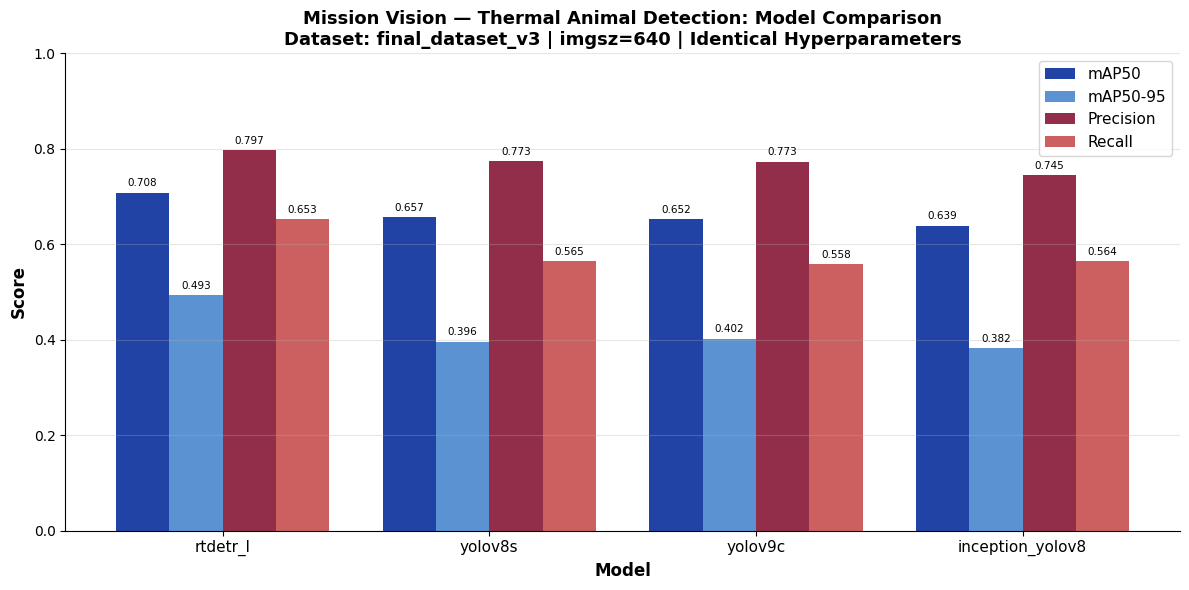

Chart saved to Drive: /content/drive/MyDrive/Colab Notebooks/sem II/thermal_animal_detection/results/comparison_chart.png


In [21]:
# ── 6.4 Plot comparison chart ──────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

models_plot   = df_final['Model'].tolist()
map50_vals    = df_final['mAP50'].tolist()
map5095_vals  = df_final['mAP50-95'].tolist()
prec_vals     = df_final['Precision'].tolist()
rec_vals      = df_final['Recall'].tolist()

x = np.arange(len(models_plot))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')

b1 = ax.bar(x - 1.5*width, map50_vals,   width, label='mAP50',     color='#092E9C', alpha=0.9)
b2 = ax.bar(x - 0.5*width, map5095_vals, width, label='mAP50-95',  color='#1565C0', alpha=0.7)
b3 = ax.bar(x + 0.5*width, prec_vals,    width, label='Precision',  color='#871736', alpha=0.9)
b4 = ax.bar(x + 1.5*width, rec_vals,     width, label='Recall',     color='#B71C1C', alpha=0.7)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Mission Vision — Thermal Animal Detection: Model Comparison\n'
             'Dataset: final_dataset_v3 | imgsz=640 | Identical Hyperparameters',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_plot, fontsize=11)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels on bars
for bars in [b1, b2, b3, b4]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
chart_path = f'{RESULTS_DIR}/comparison_chart.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved to Drive: {chart_path}')

---
## Section 7 — Download Everything for GitHub
Creates a clean zip of all results ready for your repo

In [22]:
# ── 7.1 Create GitHub-ready results package ────────────────────────
import shutil, zipfile
from pathlib import Path
from google.colab import files

EXPORT_DIR = '/content/mission_vision_results'
os.makedirs(EXPORT_DIR, exist_ok=True)

# Copy results table and chart
for fname in ['paper_results_table.csv', 'comparison_chart.png']:
    src = Path(RESULTS_DIR) / fname
    if src.exists():
        shutil.copy(src, EXPORT_DIR)

# Copy best weights for each model (not full checkpoints — just best.pt)
for model_name in models:
    weights_src = Path(RESULTS_DIR) / model_name / 'weights' / 'best.pt'
    metrics_src = Path(RESULTS_DIR) / model_name / 'metrics.json'
    model_export = Path(EXPORT_DIR) / model_name
    model_export.mkdir(exist_ok=True)
    if weights_src.exists():
        shutil.copy(weights_src, model_export / 'best.pt')
    if metrics_src.exists():
        shutil.copy(metrics_src, model_export / 'metrics.json')

# Copy notebook and custom architecture files
shutil.copy('/content/models/inception_backbone.py', EXPORT_DIR)
shutil.copy('/content/models/inception_yolo.yaml', EXPORT_DIR)

# Zip it
zip_path = '/content/mission_vision_results.zip'
shutil.make_archive('/content/mission_vision_results', 'zip', EXPORT_DIR)

print(f'Package created: {zip_path}')
print(f'Size: {os.path.getsize(zip_path)/1e6:.1f} MB')

# Download to your laptop
files.download(zip_path)
print('Download started.')

Package created: /content/mission_vision_results.zip
Size: 233.4 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.


---
## Section 8 — Quick Inference Test
Test any model on a single image to verify detection is working

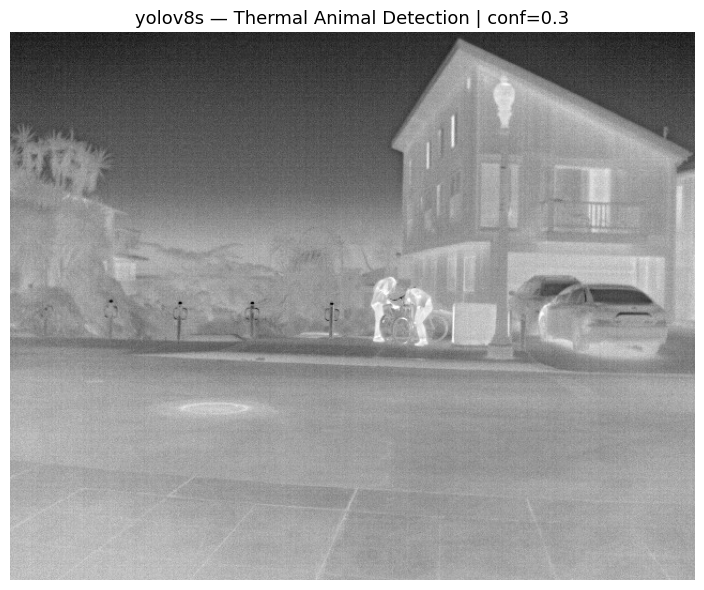

Detections: 0


In [23]:
# ── 8.1 Test inference on a validation image ───────────────────────
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import random

# Pick any model to test — change model_name to test others
model_name = 'yolov8s'  # change to: yolov9c, rtdetr_l, inception_yolov8
weights_path = f'{RESULTS_DIR}/{model_name}/weights/best.pt'

if model_name == 'inception_yolov8':
    import sys
    sys.path.insert(0, '/content/models')
    from inception_backbone import InceptionModule
    import ultralytics.nn.tasks
    ultralytics.nn.tasks.__dict__['InceptionModule'] = InceptionModule

model = YOLO(weights_path)

# Pick a random val image
val_imgs = os.listdir(f'{DATASET_LOCAL}/images/val')
test_img = f'{DATASET_LOCAL}/images/val/{random.choice(val_imgs)}'

results = model.predict(test_img, conf=0.3, verbose=False)
annotated = results[0].plot()

plt.figure(figsize=(10, 6))
plt.imshow(annotated[:, :, ::-1])
plt.title(f'{model_name} — Thermal Animal Detection | conf=0.3', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()

print(f'Detections: {len(results[0].boxes)}')
if len(results[0].boxes) > 0:
    for box in results[0].boxes:
        print(f'  Confidence: {box.conf.item():.3f}')